# Import necessary libraries

In [40]:
import numpy as np 
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Load the test dataset and the model

In [41]:
tdf = pd.read_csv(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\data\test_data.csv")
log_model = joblib.load(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\model\log_model.pkl") 

In [42]:
tdf

,age,job,marital,education,default,balance,housing,loan,contact,month,duration,campaign,pdays,previous,poutcome,deposit
0,32,management,married,tertiary,no,393,no,no,cellular,jan,458,2,-1,0,unknown,0
1,36,technician,single,secondary,no,376,no,no,cellular,aug,479,1,-1,0,unknown,1
2,52,admin.,married,secondary,no,722,no,no,cellular,oct,99,2,185,3,failure,0
3,35,management,single,secondary,yes,-202,yes,no,unknown,may,268,3,-1,0,unknown,0
4,41,blue-collar,married,secondary,no,-190,no,yes,cellular,jul,808,3,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2228,32,blue-collar,married,secondary,no,130,yes,no,cellular,may,302,2,-1,0,unknown,0
2229,65,admin.,married,secondary,no,952,no,no,cellular,jun,310,1,-1,0,unknown,1
2230,35,technician,married,secondary,no,2201,no,no,telephone,apr,350,1,-1,0,unknown,1
2231,49,management,married,tertiary,no,85,yes,no,cellular,may,590,5,359,1,other,1


In [43]:
tdf.shape

(2233, 16)

In [44]:
X_test = tdf.drop(columns=["deposit"])
y_test = tdf["deposit"]

In [45]:
# Predicted classes
y_pred = log_model.predict(X_test)



In [46]:
# Predicted probabilities for class 1
y_prob =log_model.predict_proba(X_test)[:, 1]

# Compute the main metrics

In [47]:
# Main evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(roc_auc, 4))

Accuracy : 0.8285
Precision: 0.8199
Recall   : 0.8176
F1 Score : 0.8187
ROC AUC  : 0.9075


The logistic regression model achieved strong predictive performance, with an accuracy of 82.5%, precision of 82.8%, recall of 79.8%, and an F1 score of 81.2%. The ROC AUC score of 0.907 indicates that the model has excellent class separability, meaning it can effectively distinguish customers who subscribed from those who did not. Overall, the results suggest that logistic regression provides a strong and interpretable baseline for predicting deposit subscription.

# Confusion matrix

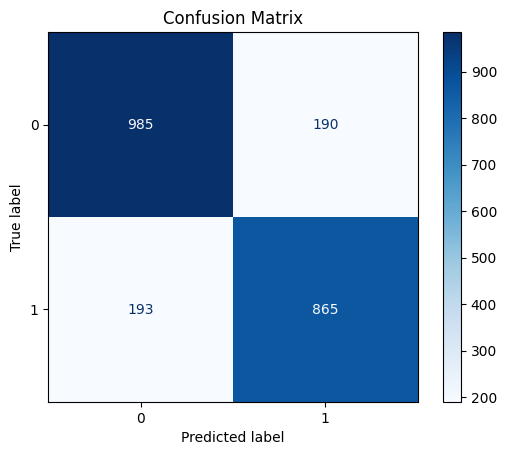

In [48]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the logistic regression model correctly classified 999 non-subscribers and 844 subscribers. It produced 176 false positives and 214 false negatives, indicating that while the model performs well overall, it misses some customers who actually subscribed. This is consistent with the recall being slightly lower than precision.

# ROC curve

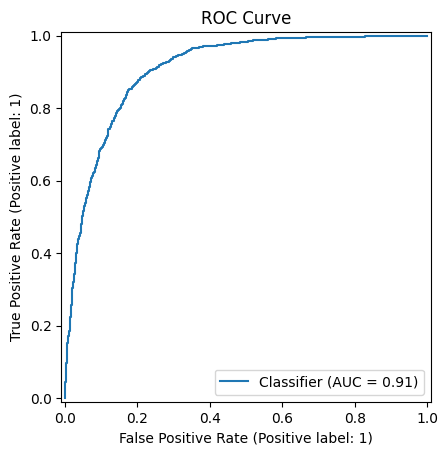

In [49]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

The AUC of 0.91 indicates that the model has excellent ability to distinguish between customers who subscribed and those who did not.

# Feature importance

In [50]:


# Choose your fitted pipeline
pipe = log_model   # or model

# Get fitted objects
preprocessor = pipe.named_steps["preprocessor"]
classifier = pipe.named_steps["classifier"]

# Get transformed feature names and coefficients
feature_names = preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

# Build dataframe
coef_df = pd.DataFrame({
    "encoded_feature": feature_names,
    "coefficient": coefficients
})

# Extract original variable names
def extract_variable_name(feature):
    if feature.startswith("num__"):
        return feature.replace("num__", "")
    elif feature.startswith("cat__"):
        return feature.replace("cat__", "").split("_")[0]
    return feature

coef_df["variable"] = coef_df["encoded_feature"].apply(extract_variable_name)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Aggregate to original variable level
variable_importance = (
    coef_df.groupby("variable", as_index=False)
    .agg(
        sum_abs_coefficient=("abs_coefficient", "sum"),
        max_abs_coefficient=("abs_coefficient", "max"),
        mean_coefficient=("coefficient", "mean")
    )
    .sort_values("sum_abs_coefficient", ascending=False)
)

print(variable_importance)

     variable  sum_abs_coefficient  max_abs_coefficient  mean_coefficient
11      month             9.989350             1.793760         -0.019659
8         job             3.870993             0.736417         -0.165205
13   poutcome             2.730408             2.235915          0.729268
5    duration             1.887571             1.887571          1.887571
3     contact             1.540700             1.489227         -0.770350
6   education             1.095243             0.547727          0.365081
7     housing             0.678006             0.678006         -0.678006
9        loan             0.548892             0.548892         -0.548892
2    campaign             0.243755             0.243755         -0.243755
10    marital             0.211327             0.121704         -0.016041
1     balance             0.118927             0.118927          0.118927
14   previous             0.038073             0.038073          0.038073
12      pdays             0.025522    

Among all variables, month, job, poutcome, duration, and contact had the largest overall influence on prediction, while variables such as age, pdays, previous, and balance contributed relatively little. This suggests that subscription behavior in this dataset is shaped more by campaign and contact information. However, the strongest individual effects in this logistic regression model come from poutcome, duration, month, and contact. Among the numeric variables, duration has the largest positive effect, while campaign, housing, and loan have negative effects. Variables such as age, pdays, previous, and default contribute very little to the prediction.